# Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reading the data

In [3]:
customers_raw_data = pd.read_csv('customers.csv')
customers_raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         162 non-null    int64 
 1   ﻿customerid        162 non-null    object
 2   entity             162 non-null    object
 3   name               162 non-null    object
 4   surname            162 non-null    object
 5   birth_date         155 non-null    object
 6   sex                155 non-null    object
 7   country            162 non-null    object
 8   state              154 non-null    object
 9   purpose            162 non-null    object
 10  deal_satisfaction  162 non-null    int64 
 11  mortgage           162 non-null    object
 12  source             162 non-null    object
dtypes: int64(2), object(11)
memory usage: 16.6+ KB


In [4]:
properties_raw_data = pd.read_csv('properties.csv')
properties_raw_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  267 non-null    int64  
 1   ﻿id         267 non-null    int64  
 2   building    267 non-null    int64  
 3   date_sale   267 non-null    object 
 4   type        267 non-null    object 
 5   property#   267 non-null    int64  
 6   area        267 non-null    float64
 7   price       267 non-null    object 
 8   status      267 non-null    object 
 9   customerid  195 non-null    object 
dtypes: float64(1), int64(4), object(5)
memory usage: 21.0+ KB


# Data Cleaning and Preprocessing

## Customers df

In [5]:
# Check column names in the customers dataset
customers = customers_raw_data.copy()
print("Customers columns:", customers.columns.tolist())
print("Customers shape:", customers.shape)

Customers columns: ['Unnamed: 0', '\ufeffcustomerid', 'entity', 'name', 'surname', 'birth_date', 'sex', 'country', 'state', 'purpose', 'deal_satisfaction', 'mortgage', 'source']
Customers shape: (162, 13)


In [6]:
# drop redundant columns
customers = customers.drop(columns='Unnamed: 0')
# rename customerid in an appropriate way
customers.columns = customers.columns.str.replace('\ufeff', '')
customers.head()

,customerid,entity,name,surname,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source
0,C0110,Individual,Kareem,Liu,5/11/1968,F,USA,California,Home,4,Yes,Website
1,C0010,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0132,Individual,Kale,Gay,4/7/1959,M,USA,California,Home,4,Yes,Agency
3,C0137,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0174,Company,Marleez,Co,NaN,NaN,USA,California,Investment,5,No,Website


In [7]:
# Check data types
customers.dtypes

customerid           object
entity               object
name                 object
surname              object
birth_date           object
sex                  object
country              object
state                object
purpose              object
deal_satisfaction     int64
mortgage             object
source               object
dtype: object

In [8]:
# Renaming 'entity' for representation purposes
customers = customers.rename(columns= {'entity':'individual'})
customers['individual'] = customers['individual'].str.lower().map({'individual':1,'company':0})
customers['individual']

0      1
1      1
2      1
3      1
4      0
      ..
157    1
158    1
159    1
160    1
161    1
Name: individual, Length: 162, dtype: int64

In [9]:
# Merging columns "name" and "surname" into a single column "full_name"
customers['full_name'] = customers['name'] + ' ' + customers['surname']

# dropping the original "name" and "surname" columns
customers = customers.drop(columns=['name', 'surname'], axis=1)

customers.head()

,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,C0110,1,5/11/1968,F,USA,California,Home,4,Yes,Website,Kareem Liu
1,C0010,1,11/26/1962,M,USA,California,Home,1,No,Website,Trystan Oconnor
2,C0132,1,4/7/1959,M,USA,California,Home,4,Yes,Agency,Kale Gay
3,C0137,1,11/25/1959,M,USA,California,Home,5,No,Website,Russell Gross
4,C0174,0,NaN,NaN,USA,California,Investment,5,No,Website,Marleez Co


In [10]:
# Next, we want to convert 'birth_date' to a datetime format.
# This will make it easier for us to work with this data in the future.
customers['birth_date'] = pd.to_datetime(customers['birth_date'])

# Let's check the dataframe one more time.
customers.head()

,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,C0110,1,1968-05-11,F,USA,California,Home,4,Yes,Website,Kareem Liu
1,C0010,1,1962-11-26,M,USA,California,Home,1,No,Website,Trystan Oconnor
2,C0132,1,1959-04-07,M,USA,California,Home,4,Yes,Agency,Kale Gay
3,C0137,1,1959-11-25,M,USA,California,Home,5,No,Website,Russell Gross
4,C0174,0,NaT,NaN,USA,California,Investment,5,No,Website,Marleez Co


In [11]:
# Now, let's examine the 'sex' variable.
customers['sex'].unique()

# It appears there are three options: 'F', 'M', and an empty string. 
# By mapping 'F' to 1 and 'M' to 0, we can create a binary variable for sex.
customers['sex'] = customers['sex'].map({'F': 1, 'M': 0, '': pd.NA})

In [12]:
# apply lower() to the 'purpose' and 'source' columns.
customers['purpose'] = customers['purpose'].str.lower()
customers['source'] = customers['source'].str.lower()

# Let's have a look at the changes.
customers.head()

,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,C0110,1,1968-05-11,1,USA,California,home,4,Yes,website,Kareem Liu
1,C0010,1,1962-11-26,0,USA,California,home,1,No,website,Trystan Oconnor
2,C0132,1,1959-04-07,0,USA,California,home,4,Yes,agency,Kale Gay
3,C0137,1,1959-11-25,0,USA,California,home,5,No,website,Russell Gross
4,C0174,0,NaT,NaN,USA,California,investment,5,No,website,Marleez Co


In [13]:
# Now, let's move on to 'mortgage'. We'll map 'No' to 0 and 'Yes' to 1.
customers['mortgage'] = customers['mortgage'].map({'No':0,'Yes':1})

# Let's see how the dataframe looks now.
customers.head()

,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,C0110,1,1968-05-11,1,USA,California,home,4,1,website,Kareem Liu
1,C0010,1,1962-11-26,0,USA,California,home,1,0,website,Trystan Oconnor
2,C0132,1,1959-04-07,0,USA,California,home,4,1,agency,Kale Gay
3,C0137,1,1959-11-25,0,USA,California,home,5,0,website,Russell Gross
4,C0174,0,NaT,NaN,USA,California,investment,5,0,website,Marleez Co


In [14]:
customers.isna().sum()

customerid           0
individual           0
birth_date           7
sex                  7
country              0
state                8
purpose              0
deal_satisfaction    0
mortgage             0
source               0
full_name            0
dtype: int64

## Properties df

In [15]:
properties = properties_raw_data.copy()
print("Properties columns:", properties.columns.tolist())
print("Properties shape:", properties.shape)

Properties columns: ['Unnamed: 0', '\ufeffid', 'building', 'date_sale', 'type', 'property#', 'area', 'price', 'status', 'customerid']
Properties shape: (267, 10)


In [16]:
# drop redundant columns
properties = properties.drop(columns='Unnamed: 0')
properties.head()

,﻿id,building,date_sale,type,property#,area,price,status,customerid
0,1030,1,11/1/2005,Apartment,30,743.09,"$246,172.68",Sold,C0028
1,1029,1,10/1/2005,Apartment,29,756.21,"$246,331.90",Sold,C0027
2,2002,2,7/1/2007,Apartment,2,587.28,"$209,280.91",Sold,C0112
3,2031,2,12/1/2007,Apartment,31,1604.75,"$452,667.01",Sold,C0160
4,1049,1,11/1/2004,Apartment,49,1375.45,"$467,083.31",Sold,C0014


In [17]:
# Check data types
properties.dtypes

id             int64
building        int64
date_sale      object
type           object
property#       int64
area          float64
price          object
status         object
customerid     object
dtype: object

#### Adjusting columns data types

In [18]:
# # By converting the 'id' column to string, we can ensure that it is treated as
# #     a categorical variable rather than a numerical one. 
# # This can be important for certain analyses and visualizations where
# #     the 'id' should not be interpreted as a continuous variable.

#properties['id'] = properties['id'].astype(str)

# # However an error occurs when excuting the above line of code due to mismatch in column name.

In [19]:
# By taking a closer look at the column values
properties.columns.array

# It appears we've stumbled upon an encoding issue.
# '\ufeff' is the Byte Order Mark (BOM) character. 
#   It's a hidden Unicode character that appears at the start of text files.

<NumpyExtensionArray>
[  '\ufeffid',   'building',  'date_sale',       'type',  'property#',
       'area',      'price',     'status', 'customerid']
Length: 9, dtype: object

In [20]:
properties.columns = properties.columns.str.replace('\ufeff', '')
properties.head()

,id,building,date_sale,type,property#,area,price,status,customerid
0,1030,1,11/1/2005,Apartment,30,743.09,"$246,172.68",Sold,C0028
1,1029,1,10/1/2005,Apartment,29,756.21,"$246,331.90",Sold,C0027
2,2002,2,7/1/2007,Apartment,2,587.28,"$209,280.91",Sold,C0112
3,2031,2,12/1/2007,Apartment,31,1604.75,"$452,667.01",Sold,C0160
4,1049,1,11/1/2004,Apartment,49,1375.45,"$467,083.31",Sold,C0014


In [21]:
# with the column name issue resolved, we can now proceed to convert 'id' to a string.
properties['id'] = properties['id'].astype(str)
properties['id']

0      1030
1      1029
2      2002
3      2031
4      1049
       ... 
262    5044
263    5047
264    5048
265    5050
266    5051
Name: id, Length: 267, dtype: object

In [22]:
# The same applies for the 'building' and 'property#' variables
properties['building'] = properties['building'].astype(str)
properties['property#'] = properties['property#'].astype(str)

# check the new data types
properties.dtypes

id             object
building       object
date_sale      object
type           object
property#      object
area          float64
price          object
status         object
customerid     object
dtype: object

In [23]:
# Function to clean currency values
def clean_currency(column):
    return (
        column.astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '', regex=False)
        .apply(pd.to_numeric, errors='coerce')
    )
properties['price'] = clean_currency(properties['price'])
print("=== AFTER CLEANING PRICE COLUMN===")
print(properties['price'].head())

=== AFTER CLEANING PRICE COLUMN===
0    246172.68
1    246331.90
2    209280.91
3    452667.01
4    467083.31
Name: price, dtype: float64


In [24]:
# Focusing on 'date of sale'
properties['date_sale'].unique()

array(['11/1/2005', '10/1/2005', '7/1/2007', '12/1/2007', '11/1/2004',
       '9/1/2007', '1/1/2008', '6/1/2006', '3/1/2006', '10/1/2004',
       '8/1/2006', '10/1/2007', '11/1/2006', '4/1/2007', '10/1/2006',
       '12/1/2006', '3/1/2005', '3/1/2007', '9/1/2006', '1/1/2007',
       '5/1/2007', '7/1/2006', '5/1/2008', '11/1/2007', '1/1/2005',
       '8/1/2007', '6/1/2005', '2/1/2007', '6/1/2007', '2/1/2005',
       '8/1/2004', '12/1/2008', '5/1/2010', '4/1/2006', '8/1/2005',
       '6/1/2004', '12/1/2005', '3/1/2004', '2/1/2006', '4/1/2005',
       '5/1/2006', '#NUM!', '9/1/2005', '7/1/2005'], dtype=object)

In [25]:
# first, replace the Excel-specific missing value indicator '#NUM!' with a format 
#   that pandas can understand as a null value, i.e., 'pd.NA'.
# A convenient way to implement this substitution is using the 'np.where' function from the NumPy library.
properties['date_sale'] = np.where(properties['date_sale']=='#NUM!', pd.NA, properties['date_sale'])

In [26]:
# Rechecking the unique entries
properties['date_sale'].unique()

array(['11/1/2005', '10/1/2005', '7/1/2007', '12/1/2007', '11/1/2004',
       '9/1/2007', '1/1/2008', '6/1/2006', '3/1/2006', '10/1/2004',
       '8/1/2006', '10/1/2007', '11/1/2006', '4/1/2007', '10/1/2006',
       '12/1/2006', '3/1/2005', '3/1/2007', '9/1/2006', '1/1/2007',
       '5/1/2007', '7/1/2006', '5/1/2008', '11/1/2007', '1/1/2005',
       '8/1/2007', '6/1/2005', '2/1/2007', '6/1/2007', '2/1/2005',
       '8/1/2004', '12/1/2008', '5/1/2010', '4/1/2006', '8/1/2005',
       '6/1/2004', '12/1/2005', '3/1/2004', '2/1/2006', '4/1/2005',
       '5/1/2006', <NA>, '9/1/2005', '7/1/2005'], dtype=object)

In [27]:
# then, convert the 'date_sale' column to a date type. 
properties['date_sale'] = pd.to_datetime(properties['date_sale'])
properties['date_sale']

0     2005-11-01
1     2005-10-01
2     2007-07-01
3     2007-12-01
4     2004-11-01
         ...    
262          NaT
263          NaT
264          NaT
265          NaT
266          NaT
Name: date_sale, Length: 267, dtype: datetime64[ns]

#### Reformatting Attributes

In [28]:
print(properties['type'].unique())

# .lower() method applied for standardization, ensuring consistency in the 'type' column values.
properties['type'] = properties['type'].str.lower()

['Apartment' 'Office']


In [29]:
print(properties['status'].unique())
# .strip() and .lower() methods applied for standardization, ensuring consistency in the 'status' column values
properties['status'] = properties['status'].str.strip().str.lower()

[' Sold ' '-']


In [30]:
# Renaming the 'status' column to 'sold' and mapping its values to binary representation (1 for 'sold', 0 for '-').
properties = properties.rename(columns= {'status':'sold'})
properties['sold'] = properties['sold'].map({'sold':1,'-':0})
# Let's view the unique values in 'sold' to confirm our transformations.
properties['sold'].unique()

array([1, 0])

In [31]:
properties.dtypes

id                    object
building              object
date_sale     datetime64[ns]
type                  object
property#             object
area                 float64
price                float64
sold                   int64
customerid            object
dtype: object

In [32]:
properties.isnull().sum()

id             0
building       0
date_sale     72
type           0
property#      0
area           0
price          0
sold           0
customerid    72
dtype: int64

In [33]:
# To wrap up the cleaning process, let's take a look at our final, tidied dataset.
properties

,id,building,date_sale,type,property#,area,price,sold,customerid
0,1030,1,2005-11-01,apartment,30,743.09,246172.68,1,C0028
1,1029,1,2005-10-01,apartment,29,756.21,246331.90,1,C0027
2,2002,2,2007-07-01,apartment,2,587.28,209280.91,1,C0112
3,2031,2,2007-12-01,apartment,31,1604.75,452667.01,1,C0160
4,1049,1,2004-11-01,apartment,49,1375.45,467083.31,1,C0014
...,...,...,...,...,...,...,...,...,...
262,5044,5,NaT,apartment,44,1238.58,322610.74,0,NaN
263,5047,5,NaT,apartment,47,794.52,279191.26,0,NaN
264,5048,5,NaT,apartment,48,1013.27,287996.53,0,NaN
265,5050,5,NaT,apartment,50,1074.71,365868.78,0,NaN


## Merging both dataframes

In [34]:
print("Number of unique customers in properties : ", properties['customerid'].nunique())
print("Number of unique customers in customers : ", customers['customerid'].nunique())

Number of unique customers in properties :  162
Number of unique customers in customers :  162


In [35]:
pd.merge(properties, customers, on='customerid',how='left')

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,1030,1,2005-11-01,apartment,30,743.09,246172.68,1,C0028,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1029,1,2005-10-01,apartment,29,756.21,246331.90,1,C0027,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,2,2007-07-01,apartment,2,587.28,209280.91,1,C0112,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2031,2,2007-12-01,apartment,31,1604.75,452667.01,1,C0160,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1049,1,2004-11-01,apartment,49,1375.45,467083.31,1,C0014,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
262,5044,5,NaT,apartment,44,1238.58,322610.74,0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,5047,5,NaT,apartment,47,794.52,279191.26,0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,5048,5,NaT,apartment,48,1013.27,287996.53,0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,5050,5,NaT,apartment,50,1074.71,365868.78,0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
print(customers.customerid.count(),customers.customerid.nunique())
print(properties.customerid.count(),properties.customerid.nunique())

162 162
195 162


In [37]:
properties.customerid.unique()

array([' C0028 ', ' C0027 ', ' C0112 ', ' C0160 ', ' C0014 ', ' C0125 ',
       ' C0166 ', ' C0034 ', ' C0170 ', ' C0009 ', ' C0041 ', ' C0057 ',
       ' C0061 ', ' C0089 ', ' C0159 ', ' C0171 ', ' C0042 ', ' C0093 ',
       ' C0051 ', ' C0064 ', ' C0128 ', ' C0019 ', ' C0037 ', ' C0127 ',
       ' C0018 ', ' C0040 ', ' C0080 ', ' C0083 ', ' C0085 ', ' C0091 ',
       ' C0007 ', ' C0048 ', ' C0065 ', ' C0096 ', ' C0164 ', ' C0038 ',
       ' C0087 ', ' C0142 ', ' C0015 ', ' C0122 ', ' C0017 ', ' C0020 ',
       ' C0086 ', ' C0150 ', ' C0156 ', ' C0169 ', ' C0022 ', ' C0072 ',
       ' C0136 ', ' C0149 ', ' C0011 ', ' C0073 ', ' C0110 ', ' C0111 ',
       ' C0123 ', ' C0070 ', ' C0075 ', ' C0076 ', ' C0105 ', ' C0135 ',
       ' C0153 ', ' C0047 ', ' C0060 ', ' C0066 ', ' C0068 ', ' C0090 ',
       ' C0095 ', ' C0151 ', ' C0162 ', ' C0010 ', ' C0054 ', ' C0056 ',
       ' C0081 ', ' C0084 ', ' C0016 ', ' C0035 ', ' C0062 ', ' C0099 ',
       ' C0114 ', ' C0006 ', ' C0053 ', ' C0069 ', 

In [38]:
properties['customerid'] = properties['customerid'].str.strip()

In [39]:
properties['customerid'] = properties['customerid'].where(properties['customerid']!='', pd.NA)

In [40]:
# checking the unique values in the 'customerid' column of the properties dataset 
#   after replacing 'nan' with pd.NA
properties.customerid.unique()

array(['C0028', 'C0027', 'C0112', 'C0160', 'C0014', 'C0125', 'C0166',
       'C0034', 'C0170', 'C0009', 'C0041', 'C0057', 'C0061', 'C0089',
       'C0159', 'C0171', 'C0042', 'C0093', 'C0051', 'C0064', 'C0128',
       'C0019', 'C0037', 'C0127', 'C0018', 'C0040', 'C0080', 'C0083',
       'C0085', 'C0091', 'C0007', 'C0048', 'C0065', 'C0096', 'C0164',
       'C0038', 'C0087', 'C0142', 'C0015', 'C0122', 'C0017', 'C0020',
       'C0086', 'C0150', 'C0156', 'C0169', 'C0022', 'C0072', 'C0136',
       'C0149', 'C0011', 'C0073', 'C0110', 'C0111', 'C0123', 'C0070',
       'C0075', 'C0076', 'C0105', 'C0135', 'C0153', 'C0047', 'C0060',
       'C0066', 'C0068', 'C0090', 'C0095', 'C0151', 'C0162', 'C0010',
       'C0054', 'C0056', 'C0081', 'C0084', 'C0016', 'C0035', 'C0062',
       'C0099', 'C0114', 'C0006', 'C0053', 'C0069', 'C0077', 'C0168',
       'C0058', 'C0107', 'C0131', 'C0144', 'C0098', 'C0130', 'C0141',
       'C0067', 'C0082', 'C0113', 'C0132', 'C0137', 'C0155', 'C0163',
       'C0039', 'C00

In [41]:
# Remove spaces from all object columns
def strip_all_strings(df):
    df_clean = df.copy()
    
    # Identify string columns
    string_columns = df_clean.select_dtypes(include=['object']).columns
    
    # Apply stripping to all string columns
    for col in string_columns:
        df_clean[col] = df_clean[col].astype(str).str.strip()
    
    return df_clean

properties = strip_all_strings(properties)
customers = strip_all_strings(customers)

In [42]:
real_estate_data = pd.merge(properties, customers, on='customerid',how='left')

In [43]:
real_estate_data.tail()

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
262,5044,5,NaT,apartment,44,1238.58,322610.74,0,nan,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,5047,5,NaT,apartment,47,794.52,279191.26,0,nan,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
264,5048,5,NaT,apartment,48,1013.27,287996.53,0,nan,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
265,5050,5,NaT,apartment,50,1074.71,365868.78,0,nan,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
266,5051,5,NaT,apartment,51,789.25,199216.40,0,nan,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
real_estate_data.fillna(pd.NA, inplace=True)

# Statistics

In [45]:
data = real_estate_data.copy()

In [46]:
data.head()

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,1030,1,2005-11-01,apartment,30,743.09,246172.68,1,C0028,1.0,1986-06-21,1,USA,California,home,5.0,0.0,website,Madalyn Mercer
1,1029,1,2005-10-01,apartment,29,756.21,246331.90,1,C0027,1.0,1983-02-24,1,USA,California,home,5.0,0.0,website,Lara Carrillo
2,2002,2,2007-07-01,apartment,2,587.28,209280.91,1,C0112,1.0,1985-12-27,0,USA,California,home,1.0,1.0,client,Donavan Flowers
3,2031,2,2007-12-01,apartment,31,1604.75,452667.01,1,C0160,1.0,1985-12-27,0,USA,California,investment,3.0,1.0,website,Darien Dorsey
4,1049,1,2004-11-01,apartment,49,1375.45,467083.31,1,C0014,1.0,1979-05-15,1,USA,California,home,4.0,0.0,agency,Alessandra Perry


In [48]:
data.describe(include="all")

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
count,267,267,195,267,267,267.000000,267.000000,267.000000,267,195.000000,178,195,195,195,195,195.000000,195.000000,195,195
unique,240,5,NaN,2,59,NaN,NaN,NaN,163,NaN,NaN,3,8,10,2,NaN,NaN,3,162
top,1047,3,NaN,apartment,34,NaN,NaN,NaN,nan,NaN,NaN,0,USA,California,home,NaN,NaN,website,Marleez Co
freq,2,63,NaN,259,7,NaN,NaN,NaN,72,NaN,NaN,108,177,120,119,NaN,NaN,119,9
mean,NaN,NaN,2006-11-08 14:38:46.153846272,NaN,NaN,936.221311,281171.901386,0.730337,NaN,0.912821,1961-01-08 11:35:43.820224704,NaN,NaN,NaN,NaN,3.600000,0.317949,NaN,NaN
min,NaN,NaN,2004-03-01 00:00:00,NaN,NaN,410.710000,117564.070000,0.000000,NaN,0.000000,1931-02-13 00:00:00,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN
25%,NaN,NaN,2006-04-16 00:00:00,NaN,NaN,756.210000,217553.055000,0.000000,NaN,1.000000,1951-05-04 06:00:00,NaN,NaN,NaN,NaN,3.000000,0.000000,NaN,NaN
50%,NaN,NaN,2007-03-01 00:00:00,NaN,NaN,798.280000,249075.660000,1.000000,NaN,1.000000,1962-09-23 00:00:00,NaN,NaN,NaN,NaN,4.000000,0.000000,NaN,NaN
75%,NaN,NaN,2007-09-01 00:00:00,NaN,NaN,1121.950000,326964.855000,1.000000,NaN,1.000000,1970-07-09 06:00:00,NaN,NaN,NaN,NaN,5.000000,1.000000,NaN,NaN
max,NaN,NaN,2010-05-01 00:00:00,NaN,NaN,1942.500000,538271.740000,1.000000,NaN,1.000000,1986-06-21 00:00:00,NaN,NaN,NaN,NaN,5.000000,1.000000,NaN,NaN


## Breakdowns by building

In [50]:
# Let's identify the unique buildings in our dataset.
data['building'].unique()

array(['1', '2', '3', '4', '5'], dtype=object)

### Breakdown of totals by building

In [ ]:
columns_to_check = ['building', 'sold','mortgage']
# grouping the data by 'building' and calculating the sum for 'sold' and 'mortgage' columns
totals_by_building = data[columns_to_check].groupby('building').sum()
totals_by_building

,sold,mortgage
building,,
1,46,14.0
2,54,18.0
3,53,15.0
4,23,9.0
5,19,6.0


### Annual sales by building

In [193]:
# Group by building and date of sale to get the total sales count for each building on each date.
columns_of_interest = ['building', 'date_sale','sold']
sales_by_building = data[columns_of_interest].groupby(['building', 'date_sale']).sum()
sales_by_building = sales_by_building.rename(columns={'sold': 'sales_count'})
sales_by_building

sales_count
building date_sale              
1        2004-03-01            2
         2004-06-01            2
         2004-08-01            2
         2004-10-01            5
         2004-11-01            4
...                          ...
5        2007-11-01            6
         2007-12-01            1
         2008-05-01            3
         2008-12-01            3
         2010-05-01            1

[76 rows x 1 columns]

In [194]:
# Convert the index to a column for easier manipulation
sales_by_building = sales_by_building.reset_index()

# Convert 'date_sale' to datetime format and extract the year
sales_by_building['date_sale'] = pd.to_datetime(sales_by_building['date_sale'])
sales_by_building['year'] = sales_by_building['date_sale'].dt.year

# Group by year and building to get annual sales
annual_sales_by_building = sales_by_building.groupby(['year', 'building'])['sales_count'].sum()
annual_sales_by_building = annual_sales_by_building.rename('annual_sales')
print(annual_sales_by_building)

year  building
2004  1           15
      2            1
2005  1           24
      2            3
2006  1            6
      2           23
      3            8
      4            2
      5            1
2007  1            1
      2           27
      3           43
      4           20
      5           11
2008  3            2
      4            1
      5            6
2010  5            1
Name: annual_sales, dtype: int64


In [162]:
# Convert annal_sales_by_building to pivot table for better visualization
annual_sales = annual_sales_by_building.reset_index().pivot(index='year', columns='building', values='annual_sales').fillna(0).astype(int)
annual_sales

building,1,2,3,4,5
year,,,,,
2004,15,1,0,0,0
2005,24,3,0,0,0
2006,6,23,8,2,1
2007,1,27,43,20,11
2008,0,0,2,1,6
2010,0,0,0,0,1


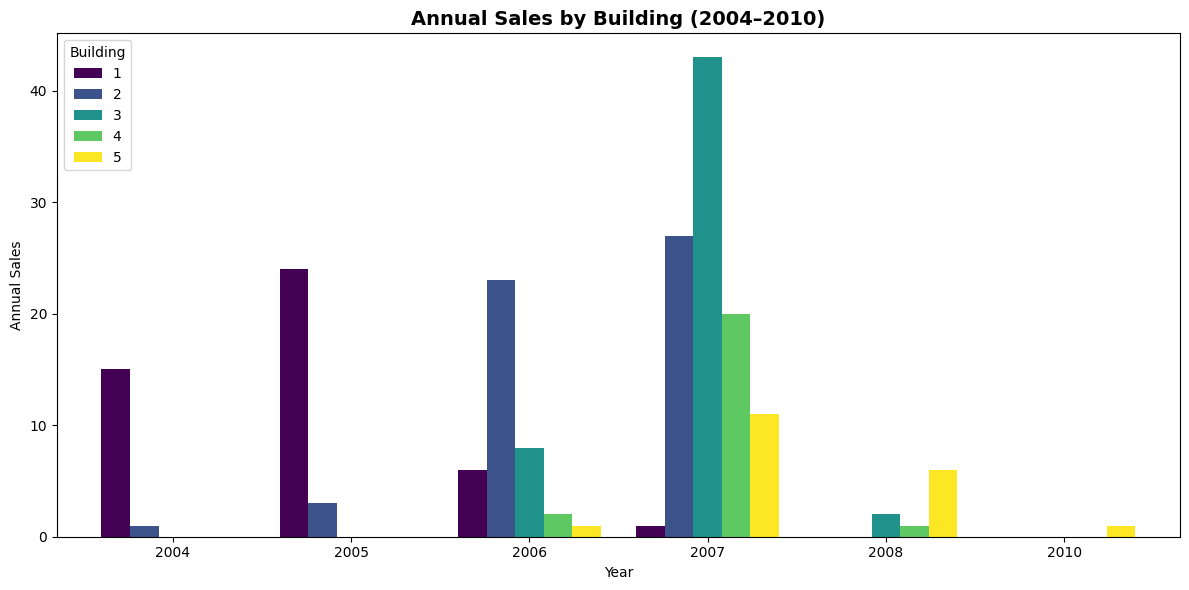

In [163]:
fig, ax = plt.subplots(figsize=(12, 6))
annual_sales.plot(kind='bar', ax=ax, width=0.8, colormap='viridis')

ax.set_title('Annual Sales by Building (2004–2010)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Annual Sales')
ax.legend(title='Building', loc='upper left')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### Show cumulative annual sales by building

In [195]:
annual_sales_by_building = annual_sales_by_building.reset_index()        

# Add cumulative sales by year
annual_sales_by_building['cumulative_sales'] = annual_sales_by_building.groupby('year')['annual_sales'].cumsum()

annual_sales_by_building = annual_sales_by_building.set_index(['year', 'building'])
annual_sales_by_building

annual_sales  cumulative_sales
year building                                
2004 1                   15                15
     2                    1                16
2005 1                   24                24
     2                    3                27
2006 1                    6                 6
     2                   23                29
     3                    8                37
     4                    2                39
     5                    1                40
2007 1                    1                 1
     2                   27                28
     3                   43                71
     4                   20                91
     5                   11               102
2008 3                    2                 2
     4                    1                 3
     5                    6                 9
2010 5                    1                 1

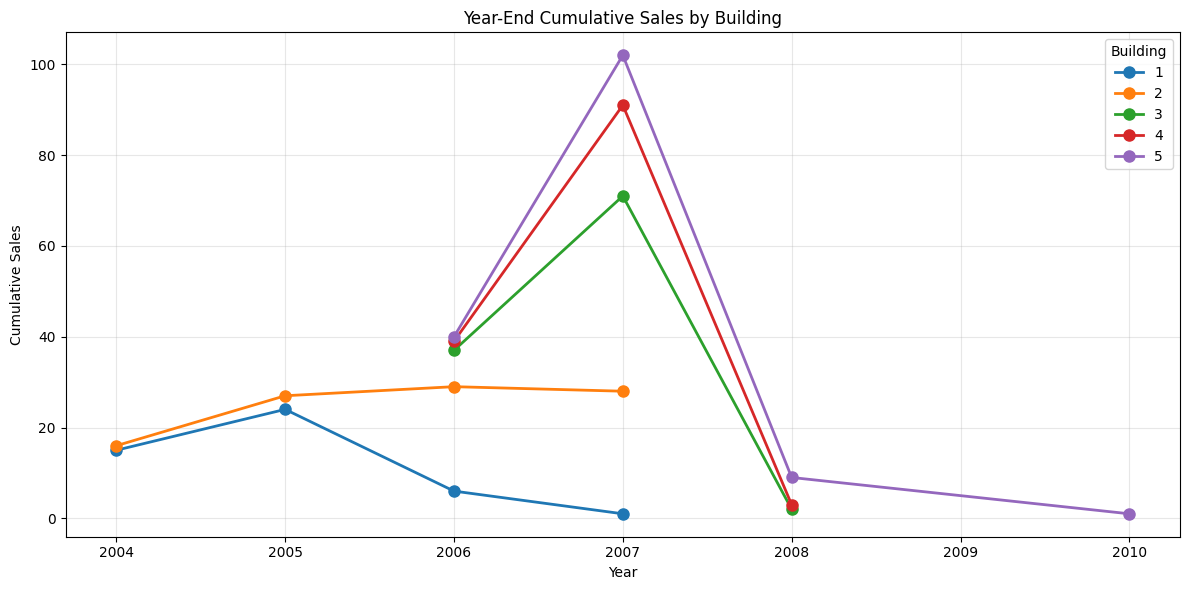

In [201]:
plt.figure(figsize=(12, 6))

# Loop through each building
for building in annual_sales_by_building.index.get_level_values('building').unique():
    subset = annual_sales_by_building.xs(building, level='building')
    plt.plot(
        subset.index.get_level_values('year'),
        subset['cumulative_sales'],
        marker='o',
        linewidth=2,
        markersize=8,
        label=f'{building}'
    )

plt.xlabel('Year')
plt.ylabel('Cumulative Sales')
plt.title('Year-End Cumulative Sales by Building')
plt.legend(title='Building')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Breakdown of averages by building

In [ ]:
columns_of_interest = ['building', 'area','price','deal_satisfaction']
# grouping the data by 'building' and calculating the mean for the specified columns
averages_by_building = data[columns_of_interest].groupby('building').mean()
averages_by_building

,area,price,deal_satisfaction
building,,,
1,928.038846,275143.242500,3.630435
2,943.891930,286661.848246,3.518519
3,927.852381,280451.255556,3.566038
4,974.720930,290239.515581,3.869565
5,914.298654,274557.604615,3.526316


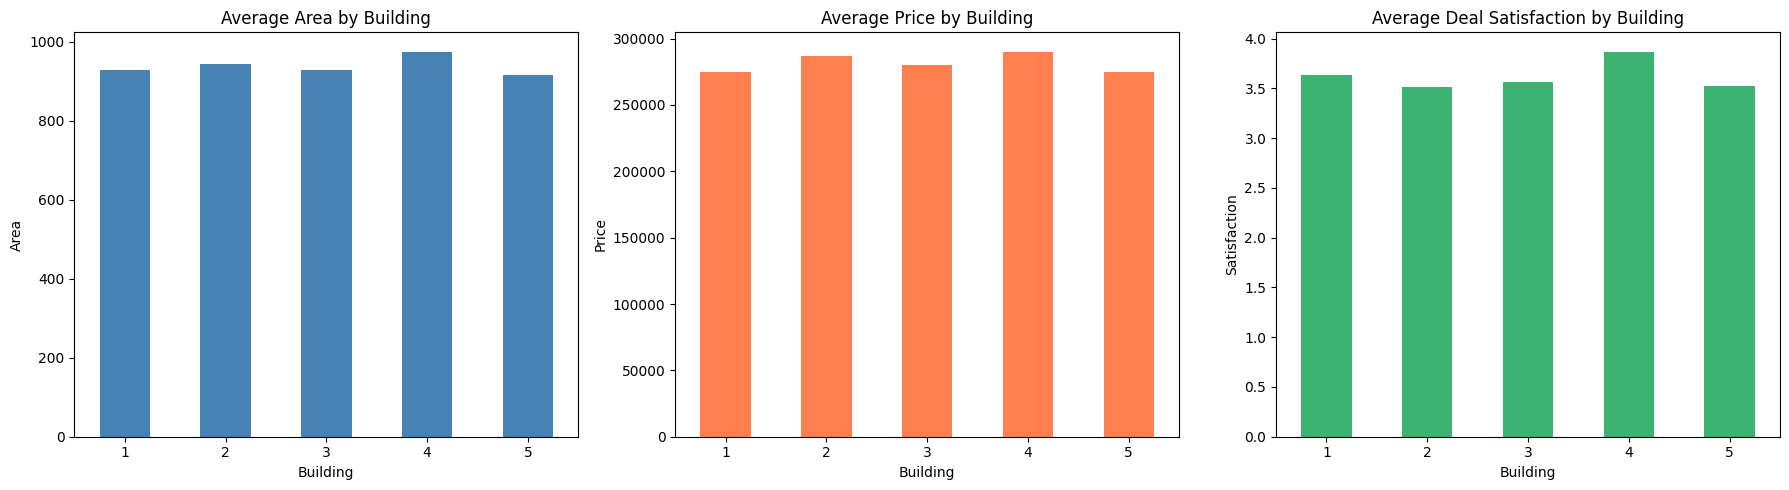

In [120]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Average Area
averages_by_building['area'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Area by Building')
axes[0].set_xlabel('Building')
axes[0].set_ylabel('Area')

# Plot 2: Average Price
averages_by_building['price'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Average Price by Building')
axes[1].set_xlabel('Building')
axes[1].set_ylabel('Price')

# Plot 3: Average Deal Satisfaction
averages_by_building['deal_satisfaction'].plot(kind='bar', ax=axes[2], color='mediumseagreen')
axes[2].set_title('Average Deal Satisfaction by Building')
axes[2].set_xlabel('Building')
axes[2].set_ylabel('Satisfaction')

plt.setp([ax.get_xticklabels() for ax in axes], rotation=0)
plt.tight_layout()
plt.show()

## Breakdowns by country and state

### Discriptive analytics by country

In [59]:
# Grouping the data by 'country' and calculating the specified aggregations
sales_by_country = data.groupby('country').agg(
    sales_count=('sold','sum'),
    avg_price=('price','mean'),
    avg_area=('area','mean'),
    avg_deal_satisfaction=('deal_satisfaction','mean')
).round(2)

sales_by_country

,sales_count,avg_price,avg_area,avg_deal_satisfaction
country,,,,
Belgium,2,229075.47,852.73,3.00
Canada,7,274069.38,917.38,5.00
Denmark,1,257183.48,785.48,1.00
Germany,1,205098.21,743.41,5.00
Mexico,1,338181.18,1283.45,3.00
Russia,4,278828.84,903.76,2.50
UK,2,220142.68,739.48,4.00
USA,177,270096.27,900.79,3.58


### Frequency distribution by state

In [77]:
columns_of_interest_state = ['state', 'sold']
# grouping the data by 'state' and calculating the sum for 'sold' and 'mort
sales_by_state = data[columns_of_interest_state].groupby('state').sum()
sales_by_state

,sold
state,
Arizona,11
California,120
Colorado,11
Kansas,1
Nevada,17
Oregon,11
Utah,5
Virginia,4
Wyoming,1


In [114]:
print(f"The total number of sales in states is: {sales_by_state.sold.sum()}")
print(f"The total number of sales in the USA is: {sales_by_country.loc['USA', 'sales_count']}")

The total number of sales in states is: 195
The total number of sales in the USA is: 177


There is a mismatch between the total sales in the USA and the sum of sales by state. 

Probably, empty strings are counted.


In [112]:
# cleaning the 'state' column by replacing empty strings with pd.NA
data['state'] = np.where(data['state']=='', pd.NA, data['state'])
# new results after filtering the data
sales_by_state_filtered = data[data['country'] == 'USA']
sales_by_state_filtered = sales_by_state_filtered[columns_of_interest_state].groupby('state').sum()
sales_by_state_filtered

,sold
state,
Arizona,9
California,118
Colorado,11
Kansas,1
Nevada,17
Oregon,11
Utah,5
Virginia,4
Wyoming,1


In [115]:

print(f"The total number of sales in states after cleaning is: {sales_by_state_filtered.sold.sum()}")

The total number of sales in states after cleaning is: 177


In [111]:
# sort the values descending
sold_by_state = sales_by_state_filtered.sort_values('sold', ascending=False)

# rename sold column for frequency clarity
sold_by_state = sold_by_state.rename(columns={'sold':'frequency'})

# compute and add relative frequency column
sold_by_state['relative_frequency'] = sold_by_state['frequency'] / sold_by_state['frequency'].sum()

# compute and add cumulative frequency column
sold_by_state['cumulative_frequency'] = sold_by_state['relative_frequency'].cumsum()
sold_by_state

,frequency,relative_frequency,cumulative_frequency
state,,,
California,118,0.666667,0.666667
Nevada,17,0.096045,0.762712
Colorado,11,0.062147,0.824859
Oregon,11,0.062147,0.887006
Arizona,9,0.050847,0.937853
Utah,5,0.028249,0.966102
Virginia,4,0.022599,0.988701
Kansas,1,0.005650,0.994350
Wyoming,1,0.005650,1.000000


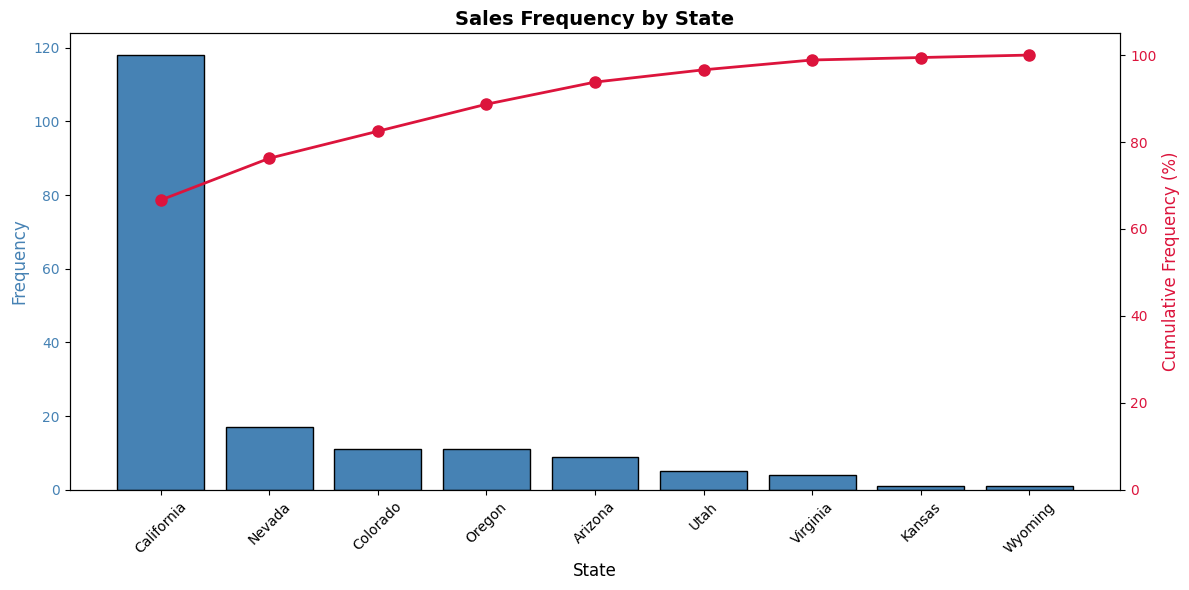

In [203]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart: Frequency
bars = ax1.bar(
    sold_by_state.index,
    sold_by_state['frequency'],
    color='steelblue',
    edgecolor='black'
)

ax1.set_xlabel('State', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

# Secondary axis: Cumulative Frequency %
ax2 = ax1.twinx()
ax2.plot(
    sold_by_state.index,
    sold_by_state['cumulative_frequency'] * 100,
    color='crimson',
    marker='o',
    linewidth=2,
    markersize=8,
    label='Cumulative %'
)
ax2.set_ylabel('Cumulative Frequency (%)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 105)


plt.title('Sales Frequency by State', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Data Analysis

## Customers Age

In [94]:
data.head()

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,birth_date,sex,country,state,purpose,deal_satisfaction,mortgage,source,full_name
0,1030,1,2005-11-01,apartment,30,743.09,246172.68,1,C0028,1.0,1986-06-21,1,USA,California,home,5.0,0.0,website,Madalyn Mercer
1,1029,1,2005-10-01,apartment,29,756.21,246331.90,1,C0027,1.0,1983-02-24,1,USA,California,home,5.0,0.0,website,Lara Carrillo
2,2002,2,2007-07-01,apartment,2,587.28,209280.91,1,C0112,1.0,1985-12-27,0,USA,California,home,1.0,1.0,client,Donavan Flowers
3,2031,2,2007-12-01,apartment,31,1604.75,452667.01,1,C0160,1.0,1985-12-27,0,USA,California,investment,3.0,1.0,website,Darien Dorsey
4,1049,1,2004-11-01,apartment,49,1375.45,467083.31,1,C0014,1.0,1979-05-15,1,USA,California,home,4.0,0.0,agency,Alessandra Perry


In [98]:
# compute the customer age by subtracting the birth date from the sale date
data['customer_age'] = data['date_sale'] - data['birth_date']
# extracting the number of years from the timedelta object to get the age in years
data['customer_age'] = data['customer_age'].dt.days // 365
data['customer_age']

0      19.0
1      22.0
2      21.0
3      21.0
4      25.0
       ... 
262     NaN
263     NaN
264     NaN
265     NaN
266     NaN
Name: customer_age, Length: 267, dtype: float64

### Breakdown by age intervals

In [ ]:
# creating age intervals using pd.cut() to categorize customer ages into 10 bins
data['age_interval'] = pd.cut(data['customer_age'], bins=10, precision=0)
# grouping the data by 'age_interval' and calculating the sum for 'sold' column
columns_of_interest_age = ['age_interval', 'sold']
sold_by_age = data[columns_of_interest_age].groupby('age_interval').sum()
sold_by_age

C:\Users\Ziad\AppData\Local\Temp\ipykernel_8448\2089966221.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sold_by_age = data[columns_of_interest_age].groupby('age_interval').sum()


,sold
age_interval,
"(19.0, 25.0]",4
"(25.0, 30.0]",16
"(30.0, 36.0]",29
"(36.0, 42.0]",30
"(42.0, 48.0]",24
"(48.0, 53.0]",22
"(53.0, 59.0]",19
"(59.0, 65.0]",12
"(65.0, 70.0]",18


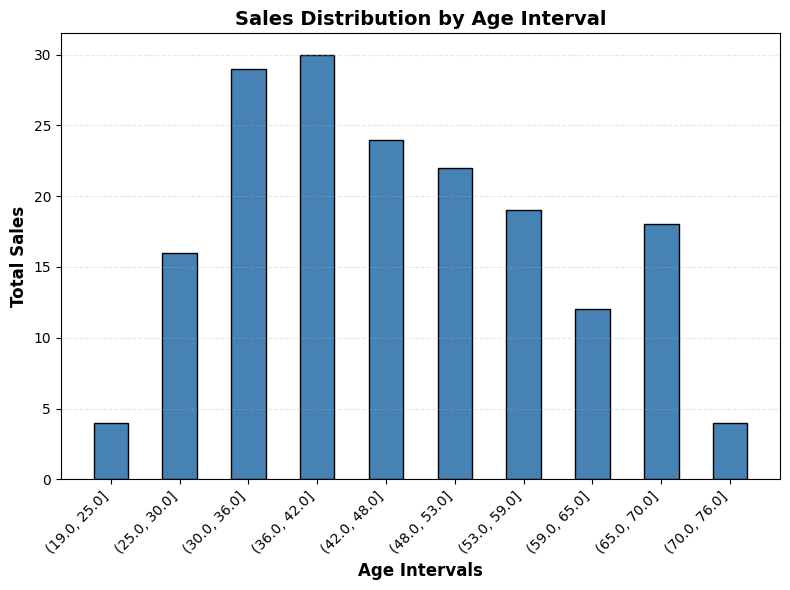

In [209]:
fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(range(len(sold_by_age)), sold_by_age['sold'].values,
    color='steelblue', edgecolor='black', width=0.5
)

ax.set_xticks(range(len(sold_by_age)))
ax.set_xticklabels(sold_by_age.index, rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Age Intervals', fontsize=12, fontweight='bold')
ax.set_ylabel('Total Sales', fontsize=12, fontweight='bold')
ax.set_title('Sales Distribution by Age Interval', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## Analysis of the price of properties

In [106]:
# creating price intervals using pd.cut() to categorize property prices into 10 bins
data['price_interval'] = pd.cut(data['price'], bins=10)

# Count the total number of properties for each price interval
columns_of_interest_price = ['price_interval', 'sold']
properties_by_price = data[columns_of_interest_price].groupby('price_interval').count()
properties_by_price = properties_by_price.rename(columns={'sold':'count'})
# Count the sold properties for each price interval
properties_by_price['sold'] = data[columns_of_interest_price].groupby('price_interval').sum()['sold']

# Calculate number of unsold properties for each price interval
properties_by_price['unsold'] = properties_by_price['count'] - properties_by_price['sold']

# Calculate the percentage of sold properties for each price interval
properties_by_price['sold_percentage'] = ((properties_by_price['sold'] / properties_by_price['count']) * 100).round(2)

properties_by_price


C:\Users\Ziad\AppData\Local\Temp\ipykernel_8448\675893243.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  properties_by_price = data[columns_of_interest_price].groupby('price_interval').count()
C:\Users\Ziad\AppData\Local\Temp\ipykernel_8448\675893243.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  properties_by_price['sold'] = data[columns_of_interest_price].groupby('price_interval').sum()['sold']


,count,sold,unsold,sold_percentage
price_interval,,,,
"(117143.362, 159634.837]",3,2,1,66.67
"(159634.837, 201705.604]",32,28,4,87.50
"(201705.604, 243776.371]",88,68,20,77.27
"(243776.371, 285847.138]",47,34,13,72.34
"(285847.138, 327917.905]",31,24,7,77.42
"(327917.905, 369988.672]",18,12,6,66.67
"(369988.672, 412059.439]",21,13,8,61.90
"(412059.439, 454130.206]",7,4,3,57.14
"(454130.206, 496200.973]",11,7,4,63.64


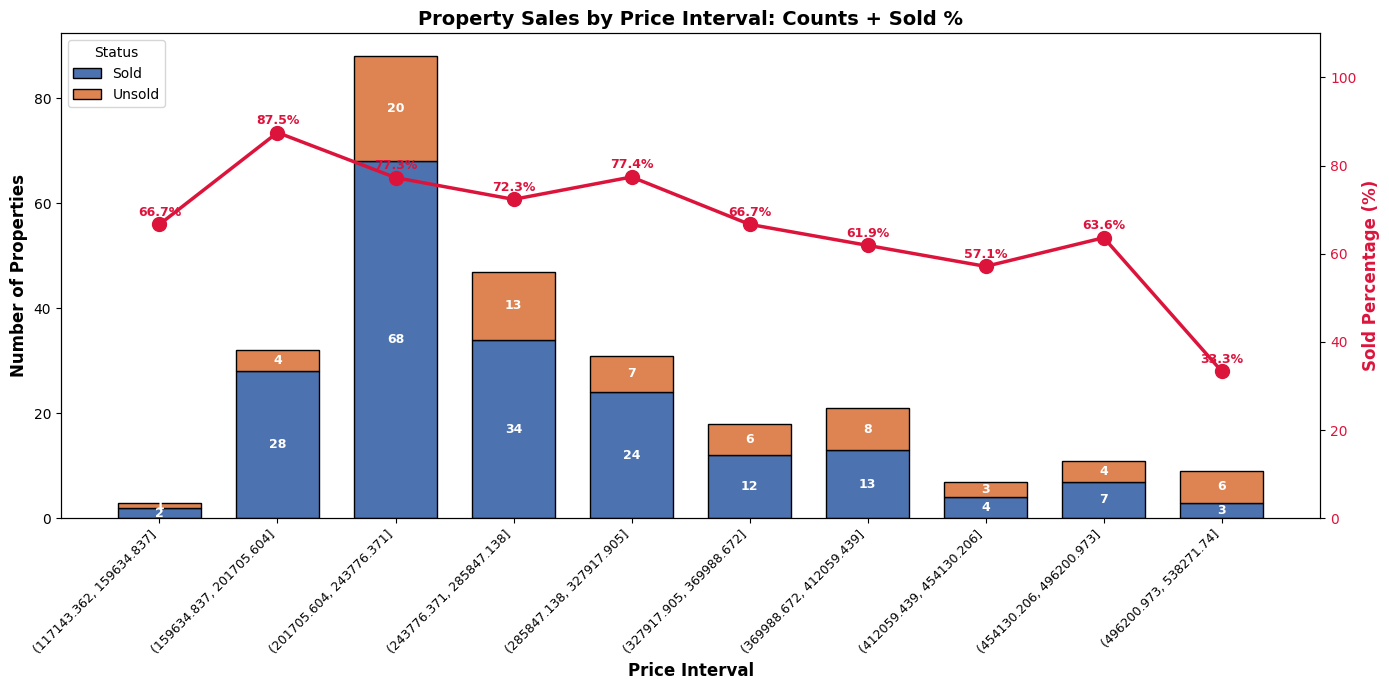

In [210]:
fig, ax1 = plt.subplots(figsize=(14, 7))

# ---- STACKED BARS: Sold + Unsold ----
x = range(len(properties_by_price))

bars_sold = ax1.bar(
    x,
    properties_by_price['sold'],
    color='#4C72B0',
    edgecolor='black',
    label='Sold',
    width=0.7
)

bars_unsold = ax1.bar(
    x,
    properties_by_price['unsold'],
    bottom=properties_by_price['sold'],
    color='#DD8452',
    edgecolor='black',
    label='Unsold',
    width=0.7
)

# Add value labels inside stacked bars
for i, (sold, unsold) in enumerate(zip(properties_by_price['sold'], properties_by_price['unsold'])):
    if sold > 0:
        ax1.text(i, sold/2, f'{int(sold)}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')
    if unsold > 0:
        ax1.text(i, sold + unsold/2, f'{int(unsold)}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')

ax1.set_xticks(x)
ax1.set_xticklabels(properties_by_price.index, rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Price Interval', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Properties', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.legend(loc='upper left', title='Status')

# ---- LINE: Sold Percentage ----
ax2 = ax1.twinx()
ax2.plot(
    x,
    properties_by_price['sold_percentage'],
    color='crimson',
    marker='o',
    linewidth=2.5,
    markersize=10,
    label='Sold %'
)

# Add percentage labels
for i, pct in enumerate(properties_by_price['sold_percentage']):
    ax2.text(i, pct + 2, f'{pct:.1f}%', ha='center', fontsize=9,
             color='crimson', fontweight='bold')

ax2.set_ylabel('Sold Percentage (%)', color='crimson', fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 110)

plt.title('Property Sales by Price Interval: Counts + Sold %',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Relationship between age and price

In [212]:
data.head()

,id,building,date_sale,type,property#,area,price,sold,customerid,individual,...,country,state,purpose,deal_satisfaction,mortgage,source,full_name,customer_age,age_interval,price_interval
0,1030,1,2005-11-01,apartment,30,743.09,246172.68,1,C0028,1.0,...,USA,California,home,5.0,0.0,website,Madalyn Mercer,19.0,"(19.0, 25.0]","(243776.371, 285847.138]"
1,1029,1,2005-10-01,apartment,29,756.21,246331.90,1,C0027,1.0,...,USA,California,home,5.0,0.0,website,Lara Carrillo,22.0,"(19.0, 25.0]","(243776.371, 285847.138]"
2,2002,2,2007-07-01,apartment,2,587.28,209280.91,1,C0112,1.0,...,USA,California,home,1.0,1.0,client,Donavan Flowers,21.0,"(19.0, 25.0]","(201705.604, 243776.371]"
3,2031,2,2007-12-01,apartment,31,1604.75,452667.01,1,C0160,1.0,...,USA,California,investment,3.0,1.0,website,Darien Dorsey,21.0,"(19.0, 25.0]","(412059.439, 454130.206]"
4,1049,1,2004-11-01,apartment,49,1375.45,467083.31,1,C0014,1.0,...,USA,California,home,4.0,0.0,agency,Alessandra Perry,25.0,"(25.0, 30.0]","(454130.206, 496200.973]"


In [213]:
# Filtering the data to include only properties that have been sold
sold_properties = data[data['sold'] == 1]   

# Keep only individual buyers
sold_properties = sold_properties[sold_properties['individual'] == 1].copy()

# Drop rows with missing age or price before measuring correlation
sold_properties_clean = sold_properties.dropna(subset=['customer_age', 'price'])

print("Correlation between age and price:", sold_properties_clean['price'].corr(sold_properties_clean['customer_age']))


Correlation between age and price: -0.1762504286382636


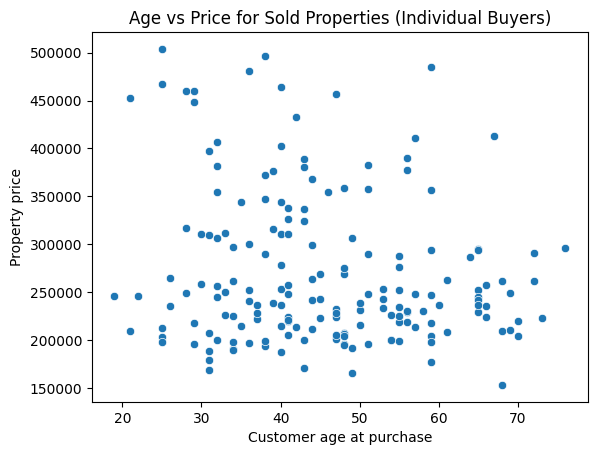

In [214]:
sns.scatterplot(data=sold_properties, x="customer_age", y="price")
plt.title('Age vs Price for Sold Properties (Individual Buyers)')
plt.xlabel('Customer age at purchase')
plt.ylabel('Property price')
plt.show()